<a href="https://colab.research.google.com/github/LorisDiotallevi/UniversityProjects/blob/main/PCA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRINCIPAL COMPONENT ANALYSIS**
*Presented by*:

*   **Elie Ghazzoul**
*   **Francesco Paolucci**
*   **Loris Diotallevi**
*   **Matteo Toschi**



## **Introduction**

The Principal Component Analysis (PCA) is a statistical method used to reduce the dimensionality of a dataset while maintaining the original informations.

The main reason to use the PCA is, as said, to reduce the dimension of the dataset; but why? For what reason is it useful?\
The main reasons are:

*   *Cleaning the noise*, some variables are redundant.
*   *Speeding up machine learning algorithms*, reducing the number of the features with a large dataset.
*   *Visualization* , New perspectives.
*   *Machine Learning*, the models learn faster.

**Limitations of PCA**


*   *Assumption of linearity*, it is a large assumption but can fail using the Kernel PCA (more dimensions to introduce no linear relation)
*   *Sensitivity to outliers*, could influence too much the principal components
*   *Need for data standardization*, using the variance this is necessary
*   *Less interpretability*, combinations of original features, i.e not direct variables.
*   *Not suitable for categorical data*, PCA works with continuous numerical
data.


## **Steps for Preparing PCA**

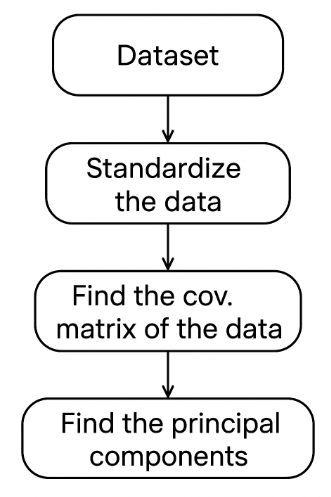

PCA transforms a set of correlated variables into a smaller set of uncorrelated variables, called principal components, where each component is a linear combination of the original variables. The component that captures the highest variance is called the first principal component. To identify the remaining components, which capture the residual variance, a decreasing order of explained variance is used. These components are orthogonal, meaning they are uncorrelated with each other.

This represents the conceptual logic behind PCA, the foundation that justifies its use.\
Now let’s move on to the mathematical perspective.


# **Eigenvectors, EigenValues and its Connection to PCA**

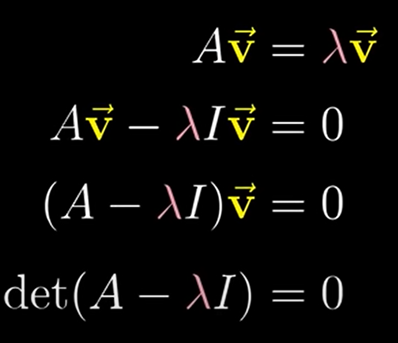

While performing PCA , we're searching to find the direction in which the data varies the most and in order to find the direction basically you need to find the *eigenvectors*. The eigenvectors are basically the principle components and these are the direction in which your data varies the most whereas the eigenvalue tells you how much variance is in each of these direction .

First of all, Imagine you have a bunch of arrows (vectors), and you feed them into your matrix-machine. Most of those arrows will change direction. But some very special arrows come out of the machine still pointing in exactly the same direction , just longer or shorter : those are eigenvectors. And the amount they grow or shrink is called the eigenvalue.

Most vectors are going to get knocked off their span during the transformation whereas eigenvector don’t.\
Eigenvectors are special because they stay on their span "they don’t rotate", just stretch and eigenvalues indicate the importance of certain behaviors in the system which behavior or trends matters the most.



In short,  Eigenvectors are the principal axes of your data and eigenvalues describes how much variance is in that principal component.\
Its important to note that in PCA we have positive eigenvalues, never negative, because it comes from the cov matrix which is always positive semi-definite.


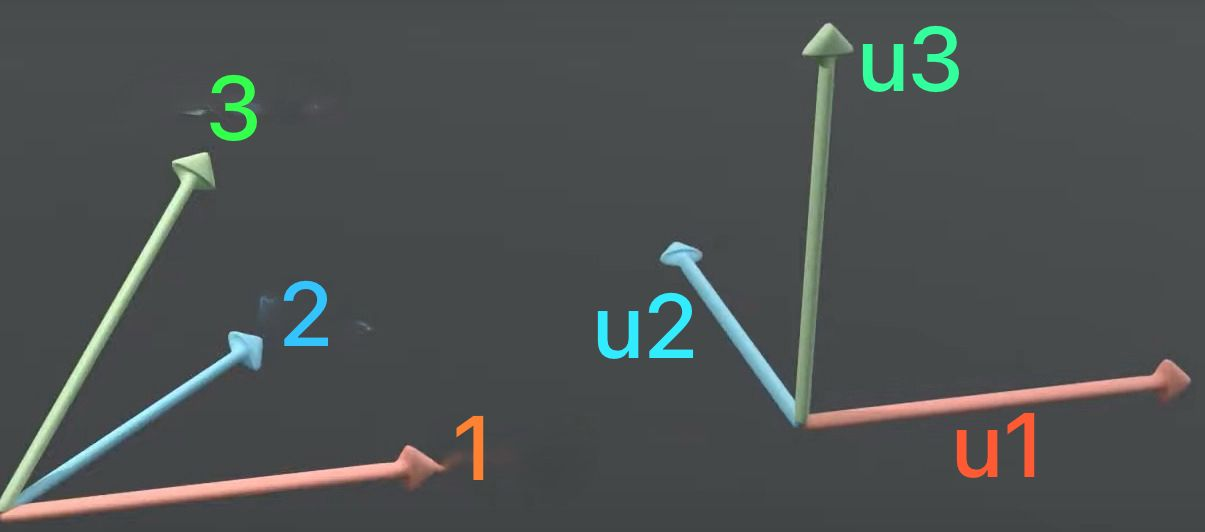

This image shows how Principal Component Analysis (PCA) transforms the original coordinate system (labeled 1, 2, 3) into a new set of orthogonal axes (u₁, u₂, u₃), which represent the principal components. Each new axis is a linear combination of the original axes — meaning u₁, u₂, and u₃ are formed by mixing the original directions with different weights. These new directions are chosen to capture the maximum variance in the data, with u₁ explaining the most, u₂ the second most, and so on. PCA effectively rotates the coordinate system to better reflect the underlying structure and patterns in the data.

PCA is trying to rotate the coordinate system (the axes) so that the first axis point in the direction where the data varies the most, the second axis to the second most variation and so on... plus they are **orthogonal**.\
This orthogonality ensures that the new axes are uncorrelated and capture distinct directions of variance in the data.

Below is a visual representation of the transformation to the axes:


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving PCA PROJ.mp4 to PCA PROJ.mp4


In [ ]:
from IPython.display import HTML
from base64 import b64encode

video_file = "PCA PROJ.mp4"

mp4 = open(video_file, 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width="640" height="360" controls>
  <source src="{data_url}" type="video/mp4">
</video>
""")


### **Your end goal eventually is to get the same data but seen from a new perspective where each new axis shows a clear direction of variability.**

### **You can choose to keep fewer axes without losing much meaning and the data becomes easier to analyze, visualize or model.**

# Practical Implementation of PCA and Classification

Now we apply **Principal Component Analysis (PCA)** to a dataset containing geometrical features of different vehicle silhouettes. The goal is to explore whether PCA can reduce dimensionality while still retaining enough information to classify the vehicles accurately using a machine learning model.

We will:
- Explore and preprocess the data
- Apply PCA and visualize the results
- Train and evaluate a **K-Nearest Neighbors (KNN)** classifier on:
  - The original features
  - The reduced sets of principal components (3 and 5 components)
- Compare the classification performance across different feature spaces

The aim is to understand if dimensionality reduction through PCA can lead to simpler yet still effective models.

**Dataset and Reference Notebook:**

The dataset used in this project is taken from [Kaggle](https://www.kaggle.com/datasets/pramodchandrayan/vehicle2) and contains numerical features describing the shapes of different vehicles.  
We also referred to this [notebook on PCA-based dimensionality reduction](https://www.kaggle.com/code/pramodchandrayan/dimensionality-reduction-using-pca/notebook) as a source of inspiration for the implementation.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/PCA/vehicle-2.csv'

# Load the dataset
df = pd.read_csv(file_path)

## Data Exploration and Preprocessing

We start by exploring the dataset to understand its structure and characteristics. This includes inspecting the shape, checking data types, identifying missing values, and summarizing the distribution of features.

Since PCA is sensitive to the scale of features, we will later **standardize** all numeric features. This ensures that each feature contributes equally to the PCA process by giving them a mean of 0 and a standard deviation of 1.

We will also look for missing values and handle them accordingly.

Finally, we will split the dataset into a training and test set to properly evaluate our model’s performance.

In [3]:
# Explore the data
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Shape of dataset: (846, 19)

First 5 rows:


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [4]:
print("\nColumn Info:")
df.info()


Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   compactness                  846 non-null    int64  
 1   circularity                  841 non-null    float64
 2   distance_circularity         842 non-null    float64
 3   radius_ratio                 840 non-null    float64
 4   pr.axis_aspect_ratio         844 non-null    float64
 5   max.length_aspect_ratio      846 non-null    int64  
 6   scatter_ratio                845 non-null    float64
 7   elongatedness                845 non-null    float64
 8   pr.axis_rectangularity       843 non-null    float64
 9   max.length_rectangularity    846 non-null    int64  
 10  scaled_variance              843 non-null    float64
 11  scaled_variance.1            844 non-null    float64
 12  scaled_radius_of_gyration    844 non-null    float64
 13  scaled

In [5]:
print("\nSummary Statistics:")
display(df.describe())


Summary Statistics:


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
count,846.000000,841.000000,842.000000,840.000000,844.000000,846.000000,845.000000,845.000000,843.000000,846.000000,843.000000,844.000000,844.000000,842.000000,840.000000,845.000000,845.000000,846.000000
mean,93.678487,44.828775,82.110451,168.888095,61.678910,8.567376,168.901775,40.933728,20.582444,147.998818,188.631079,439.494076,174.709716,72.447743,6.364286,12.602367,188.919527,195.632388
std,8.234474,6.152172,15.778292,33.520198,7.891463,4.601217,33.214848,7.816186,2.592933,14.515652,31.411004,176.666903,32.584808,7.486190,4.920649,8.936081,6.155809,7.438797
min,73.000000,33.000000,40.000000,104.000000,47.000000,2.000000,112.000000,26.000000,17.000000,118.000000,130.000000,184.000000,109.000000,59.000000,0.000000,0.000000,176.000000,181.000000
25%,87.000000,40.000000,70.000000,141.000000,57.000000,7.000000,147.000000,33.000000,19.000000,137.000000,167.000000,318.000000,149.000000,67.000000,2.000000,5.000000,184.000000,190.250000
50%,93.000000,44.000000,80.000000,167.000000,61.000000,8.000000,157.000000,43.000000,20.000000,146.000000,179.000000,363.500000,173.500000,71.500000,6.000000,11.000000,188.000000,197.000000
75%,100.000000,49.000000,98.000000,195.000000,65.000000,10.000000,198.000000,46.000000,23.000000,159.000000,217.000000,587.000000,198.000000,75.000000,9.000000,19.000000,193.000000,201.000000
max,119.000000,59.000000,112.000000,333.000000,138.000000,55.000000,265.000000,61.000000,29.000000,188.000000,320.000000,1018.000000,268.000000,135.000000,22.000000,41.000000,206.000000,211.000000


Next, we check for missing values.

In [6]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
compactness                    0
circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
max.length_aspect_ratio        0
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
max.length_rectangularity      0
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 6
skewness_about.1               1
skewness_about.2               1
hollows_ratio                  0
class                          0
dtype: int64


Since PCA requires complete data, we will remove any rows that contain missing entries.

We then split the dataset into:
- `X`: the features used for dimensionality reduction
- `y`: the target labels (vehicle class)

And we also standardized the features as already explained.

In [7]:
from sklearn.preprocessing import StandardScaler

# Drop rows with missing values
df_clean = df.dropna()

# Separate features and target
X = df_clean.drop('class', axis=1)  # Features for PCA
y = df_clean['class']               # Target (which is the vehicle type)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check results
print("Original shape:", X.shape)
print("Standardized data shape:", X_scaled.shape)

Original shape: (813, 18)
Standardized data shape: (813, 18)


### Explained Variance Analysis

We apply PCA on the full feature set to compute how much variance is explained by each principal component.

This allows us to visualize:
- The individual explained variance for each component
- The cumulative explained variance, which helps determine how many components are needed to retain most of the information

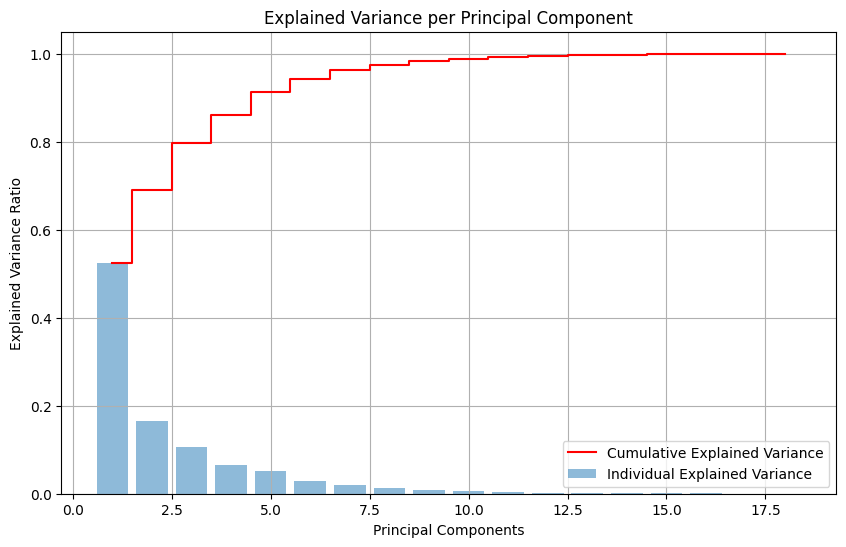

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Complete PCA on all the components
pca_all = PCA()
X_pca_all = pca_all.fit_transform(X_scaled)

# Variance explained (individual and cumulative)
var_explained = pca_all.explained_variance_ratio_
cum_var_exp = np.cumsum(var_explained)

# Bar chart + cumulative line
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(var_explained) + 1), var_explained, alpha=0.5, align='center', label='Individual Explained Variance')
plt.step(range(1, len(cum_var_exp) + 1), cum_var_exp, where='mid', label='Cumulative Explained Variance', color='red')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Explained Variance per Principal Component')
plt.legend(loc='best')
plt.grid(True)
plt.show()

### Selecting the Number of Components

In practice, we often aim to retain enough principal components to explain around 90–95% of the total variance. This allows us to reduce dimensionality while preserving most of the information in the dataset.

From the plot above, we observe that the first **5 principal components** together explain over **90%** of the variance. For this reason, we will consider these 5 components for further analysis and modeling.

### PCA Visualization with Two Components

We now project the data onto the first two principal components to visualize the distribution of the vehicle classes in a 2D space.

This step is important to understand whether PCA helps separate the different classes based on the reduced features. While PCA is an unsupervised method (it doesn't use labels), it can still uncover useful structure in the data that benefits classification tasks.

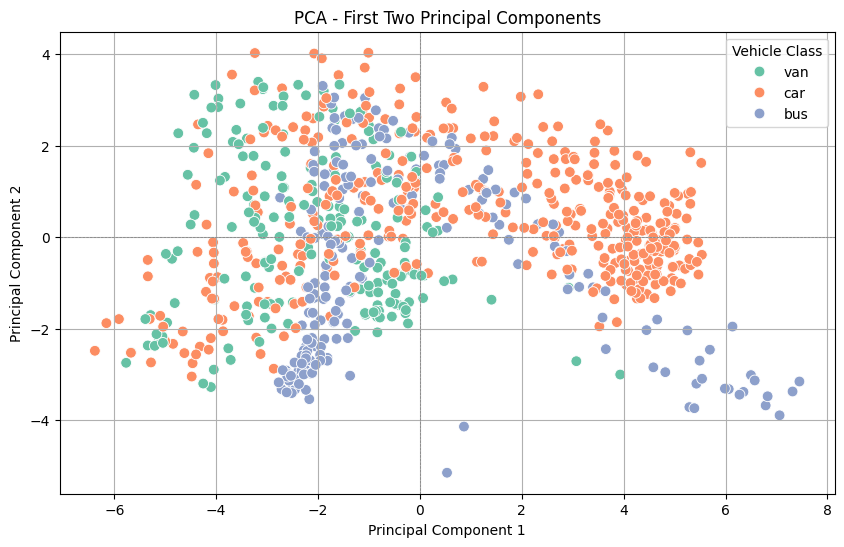

In [9]:
import seaborn as sns

# PCA with the first 2 components
pca_2d_clean = PCA(n_components=2)
X_pca_clean = pca_2d_clean.fit_transform(X_scaled)

# DataFrame for the plot
df_pca_clean = pd.DataFrame(X_pca_clean, columns=['PC1', 'PC2'])
df_pca_clean['class'] = y.values

# Scatterplot 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca_clean, x='PC1', y='PC2', hue='class', palette='Set2', s=60)
plt.title('PCA - First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.grid(True)
plt.legend(title='Vehicle Class')
plt.show()

The 2D plot shows a fairly clear separation between the three classes. The **car** class is particularly well-clustered and easily distinguishable. Although the **bus** and **van** classes overlap, they still form recognizable clusters.

This result confirms that even just two principal components capture a meaningful amount of the original structure in the dataset.

### 3D PCA Visualization (First Three Components)

To gain even more insight into how PCA captures the variance in the dataset, we now visualize the projection of the data onto the first three principal components in a 3D plot.

This view allows us to better understand the distribution of classes in a higher-dimensional space and observe any additional structure that might not be visible in 2D.

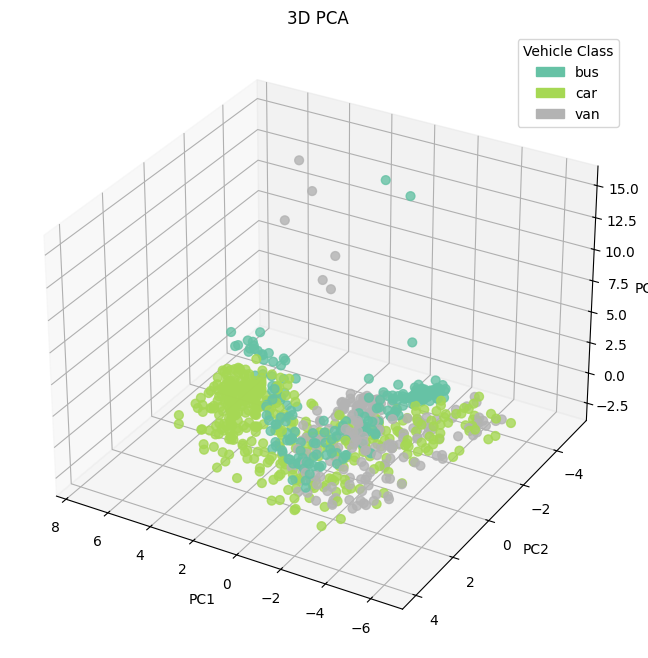

In [12]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Apply PCA with 3 components
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

# Encode class labels numerically for coloring
classes, y_encoded = np.unique(y, return_inverse=True)
colors = plt.get_cmap('Set2')(np.linspace(0, 1, len(classes)))

# Create static 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3[:, 0], X_pca_3[:, 1], X_pca_3[:, 2],
                     c=colors[y_encoded], s=40, alpha=0.8)

ax.set_title("3D PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.view_init(elev=30, azim=120)

# Legend
patches = [mpatches.Patch(color=colors[i], label=classes[i]) for i in range(len(classes))]
ax.legend(handles=patches, title="Vehicle Class", loc='upper right')

# Save figure as PNG
plt.savefig("pca_rotation_static.png", dpi=300, bbox_inches='tight')
plt.show()

The 3D visualization provides a deeper look at how well the data is separated when using three principal components.

As expected, the separation between the classes improves compared to the 2D plot. The clusters are more distinct, especially for the **car** class, while **bus** and **van** remain partially overlapping but still visually distinguishable.

This confirms that the first three components retain a substantial portion of the original information, making them useful for further dimensionality reduction and modeling.


### Pairplot of the First Five Principal Components

To further analyze how the principal components behave and interact with each other, we visualize the pairwise relationships between the first five components using a pairplot.

This allows us to explore how each pair of components contributes to separating the different vehicle classes and helps us identify which combinations might be the most informative.

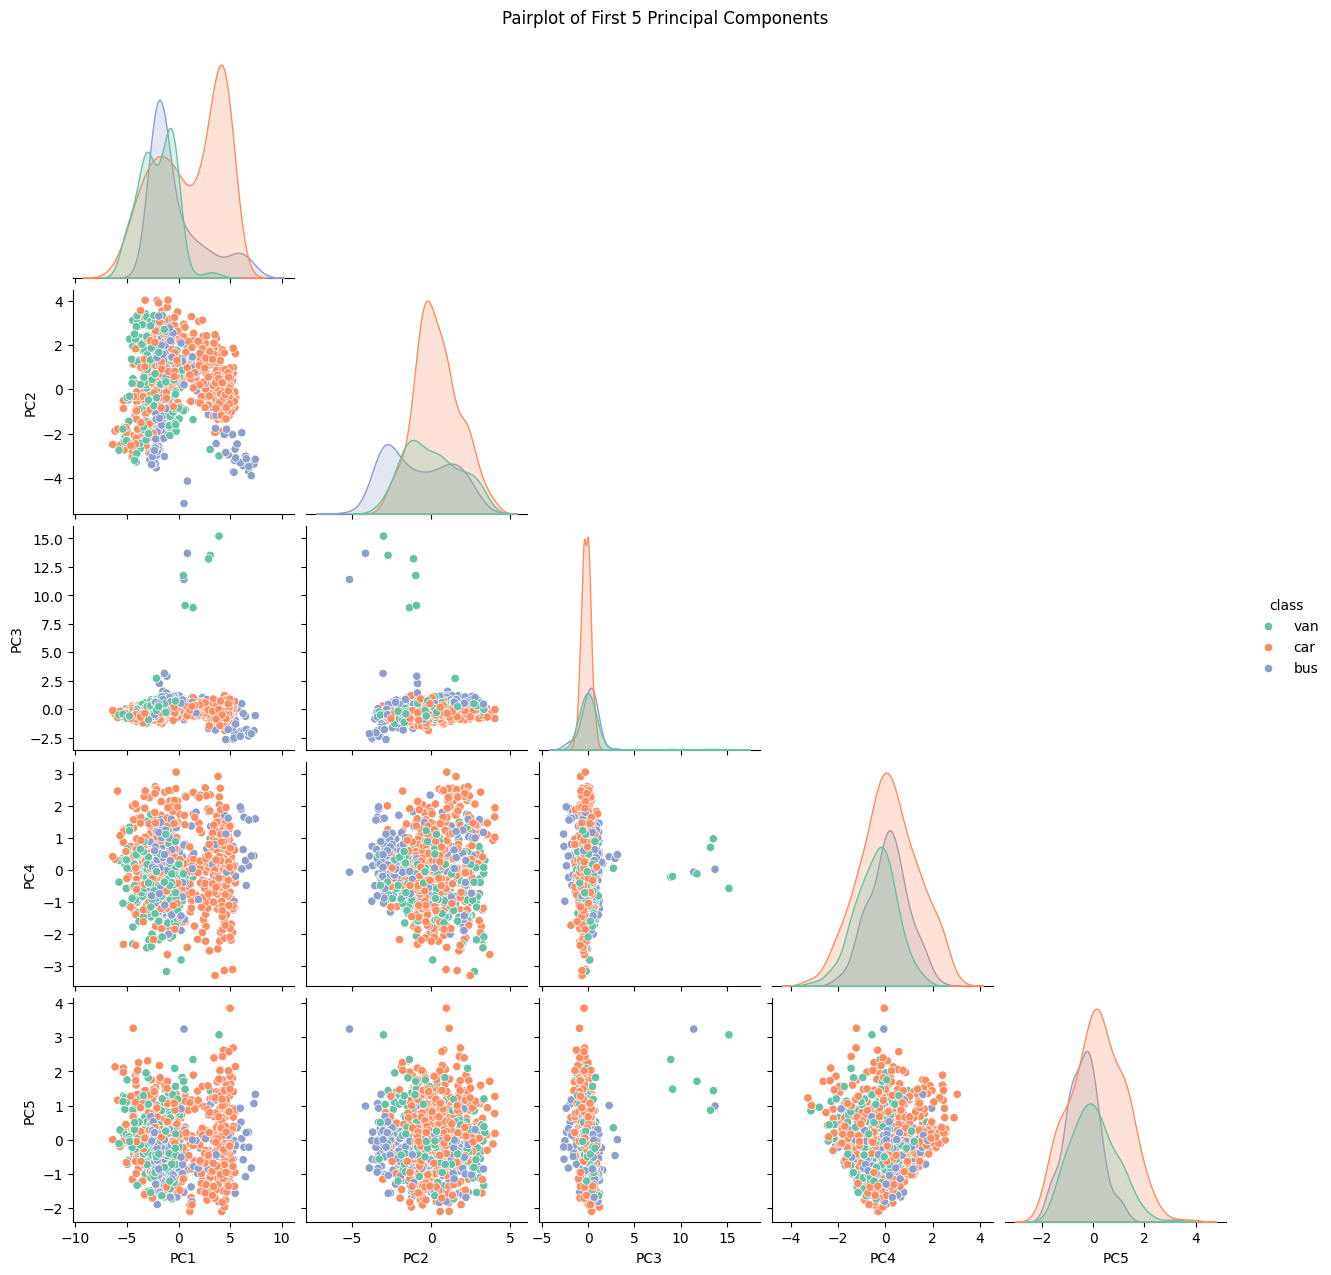

In [ ]:
# Apply PCA with 5 components
pca_5 = PCA(n_components=5)
X_pca_5 = pca_5.fit_transform(X_scaled)

# Create DataFrame with the results
df_pca_5 = pd.DataFrame(X_pca_5, columns=[f'PC{i+1}' for i in range(5)])
df_pca_5['class'] = y.values

# Create the pairplot
sns.pairplot(df_pca_5, hue='class', palette='Set2', corner=True)
plt.suptitle("Pairplot of First 5 Principal Components", y=1.02)
plt.show()

The pairplot shows that the combination of the first few components captures a reasonable amount of structure in the data.

Some pairs of components provide good separation between the classes,  particularly those involving **PC1**, **PC2**, and **PC3**, while others exhibit more overlap.

Overall, this visualization supports the idea that a reduced set of components (especially the top 3 or 5) can retain meaningful class-discriminating information, making them suitable for classification tasks.

In [ ]:
# Apply PCA on all components
pca_full = PCA()
pca_full.fit(X_scaled)

# Get the explained variance ratio for all components
explained_variance = pca_full.explained_variance_ratio_

# Calculate cumulative variance explained by the first 3 components
var_3 = np.sum(explained_variance[:3])
print(f"Total variance explained by the first 3 components: {var_3:.4f} ({var_3*100:.2f}%)")
# Calculate cumulative variance explained by the first 5 components
var_5 = np.sum(explained_variance[:5])
print(f"Total variance explained by the first 5 components: {var_5:.4f} ({var_5*100:.2f}%)")

Total variance explained by the first 3 components: 0.7968 (79.68%)
Total variance explained by the first 5 components: 0.9133 (91.33%)


### Interpreting Principal Components through Loadings

Principal components are mathematical combinations of the original features, which can make them difficult to interpret directly.

To address this, we compute and inspect the **loadings**, the coefficients that indicate how much each original feature contributes to a given principal component. This helps us better understand what each component represents in terms of the original variables.

In [ ]:
# Apply PCA with 5 components
pca_5 = PCA(n_components=5)
pca_5.fit(X_scaled)

# Create a DataFrame of loadings (components)
loadings = pd.DataFrame(
    pca_5.components_.T,  # transpose to get features as rows
    columns=[f'PC{i+1}' for i in range(5)],
    index=X.columns  # original feature names
)

# Display the loadings
print("PCA Loadings – Contribution of each original feature to the first 5 principal components:")
display(loadings)

PCA Loadings – Contribution of each original feature to the first 5 principal components:


,PC1,PC2,PC3,PC4,PC5
compactness,0.274447,0.127106,-0.115778,-0.080077,0.070197
circularity,0.294004,-0.134430,-0.036451,-0.190342,-0.086673
distance_circularity,0.304380,0.072145,-0.055188,0.069371,0.038959
radius_ratio,0.268889,0.176416,0.281805,0.044651,-0.043663
pr.axis_aspect_ratio,0.083020,0.098763,0.645769,-0.030053,-0.038468
max.length_aspect_ratio,0.098483,-0.030207,0.586412,-0.029750,0.212001
scatter_ratio,0.316689,-0.044390,-0.098585,0.094417,-0.017016
elongatedness,-0.313205,-0.015254,0.056652,-0.085067,0.075823
pr.axis_rectangularity,0.313612,-0.057231,-0.112039,0.091897,0.000739
max.length_rectangularity,0.281286,-0.120324,-0.024132,-0.192294,-0.064243


### Classification with K-Nearest Neighbors (KNN)

To evaluate the practical impact of PCA on classification performance, we applied a **K-Nearest Neighbors (KNN)** model to three different feature sets:
- The original standardized features
- The first 3 principal components
- The first 5 principal components

Using 5-fold cross-validation, we identified the **optimal number of neighbors (`k`)** for each configuration by testing values from 1 to 20. This allowed us to ensure fair comparison between models based on their best possible performance.

We then trained each KNN model with its optimal `k` on the training data and evaluated it on the test set.

We chose it as our classification model because it is simple, intuitive, and highly sensitive to the geometry of the data in feature space.

KNN works by identifying the `k` closest data points (neighbors) to a given input and assigning it the **most common class** among those neighbors. In essence, the prediction is based on a **majority vote** from the surrounding points in the feature space.

Since PCA changes the orientation and structure of the data by reducing dimensions, KNN is particularly useful to evaluate whether the transformed space still preserves enough information for accurate classification.  
If performance remains acceptable after PCA, it confirms that the most important patterns have been retained.

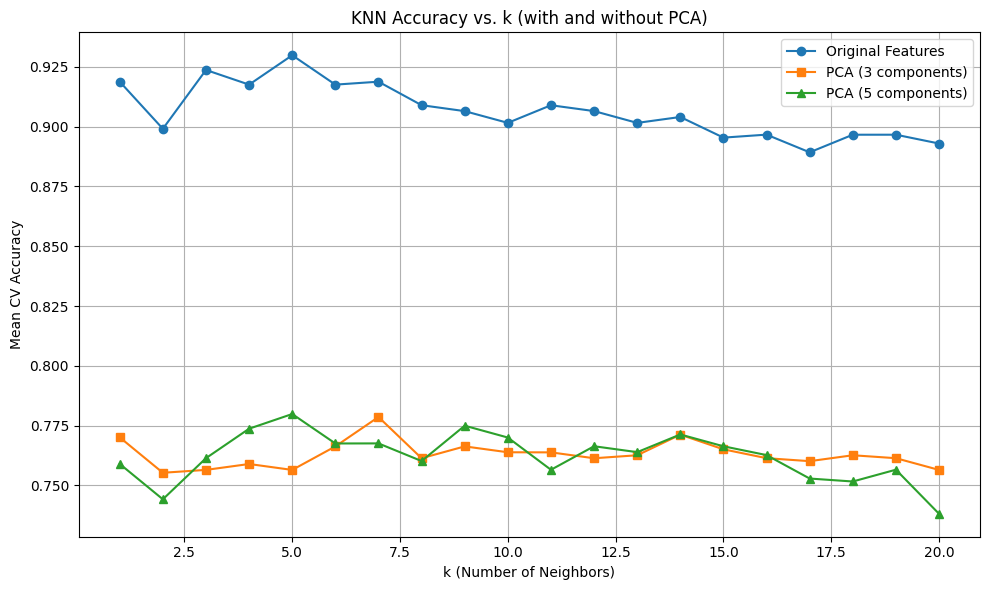

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# Define range of k values
k_values = range(1, 21)

# Lists to store mean accuracies
cv_scores_raw = []
cv_scores_pca3 = []
cv_scores_pca5 = []

# Loop through k values
for k in k_values:
    # Raw features
    knn_raw = KNeighborsClassifier(n_neighbors=k)
    scores_raw = cross_val_score(knn_raw, X_scaled, y, cv=5)
    cv_scores_raw.append(scores_raw.mean())

    # PCA with 3 components
    pipeline_3 = Pipeline([
        ('pca', PCA(n_components=3)),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores_pca3 = cross_val_score(pipeline_3, X_scaled, y, cv=5)
    cv_scores_pca3.append(scores_pca3.mean())

    # PCA with 5 components
    pipeline_5 = Pipeline([
        ('pca', PCA(n_components=5)),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores_pca5 = cross_val_score(pipeline_5, X_scaled, y, cv=5)
    cv_scores_pca5.append(scores_pca5.mean())

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores_raw, label='Original Features', marker='o')
plt.plot(k_values, cv_scores_pca3, label='PCA (3 components)', marker='s')
plt.plot(k_values, cv_scores_pca5, label='PCA (5 components)', marker='^')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Mean CV Accuracy')
plt.title('KNN Accuracy vs. k (with and without PCA)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Convert lists to numpy arrays (optional, but useful)
cv_scores_raw = np.array(cv_scores_raw)
cv_scores_pca3 = np.array(cv_scores_pca3)
cv_scores_pca5 = np.array(cv_scores_pca5)

# Get best k and corresponding accuracy for each model
best_k_raw = k_values[np.argmax(cv_scores_raw)]
best_acc_raw = cv_scores_raw.max()

best_k_pca3 = k_values[np.argmax(cv_scores_pca3)]
best_acc_pca3 = cv_scores_pca3.max()

best_k_pca5 = k_values[np.argmax(cv_scores_pca5)]
best_acc_pca5 = cv_scores_pca5.max()

# Print results
print(f"Best k for original features: {best_k_raw} (Accuracy: {best_acc_raw:.4f})")
print(f"Best k for PCA (3 components): {best_k_pca3} (Accuracy: {best_acc_pca3:.4f})")
print(f"Best k for PCA (5 components): {best_k_pca5} (Accuracy: {best_acc_pca5:.4f})")

Best k for original features: 5 (Accuracy: 0.9299)
Best k for PCA (3 components): 7 (Accuracy: 0.7786)
Best k for PCA (5 components): 5 (Accuracy: 0.7798)


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Train-test split from standardized features
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Train and predict with best k (original features)
knn_best_raw = KNeighborsClassifier(n_neighbors=best_k_raw)
knn_best_raw.fit(X_train, y_train)
y_pred_raw = knn_best_raw.predict(X_test)

# PCA (3 components)
pca_3 = PCA(n_components=3)
X_train_pca3 = pca_3.fit_transform(X_train)
X_test_pca3 = pca_3.transform(X_test)

knn_best_pca3 = KNeighborsClassifier(n_neighbors=best_k_pca3)
knn_best_pca3.fit(X_train_pca3, y_train)
y_pred_pca3 = knn_best_pca3.predict(X_test_pca3)

# PCA (5 components)
pca_5 = PCA(n_components=5)
X_train_pca5 = pca_5.fit_transform(X_train)
X_test_pca5 = pca_5.transform(X_test)

knn_best_pca5 = KNeighborsClassifier(n_neighbors=best_k_pca5)
knn_best_pca5.fit(X_train_pca5, y_train)
y_pred_pca5 = knn_best_pca5.predict(X_test_pca5)

# Function to print matrix and report
def evaluate_model(y_true, y_pred, title):
    print(f"\n{title}")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {title}")
    plt.grid(False)
    plt.show()


Original Features
              precision    recall  f1-score   support

         bus       0.93      0.98      0.95        41
         car       0.93      0.93      0.93        83
         van       0.86      0.82      0.84        39

    accuracy                           0.91       163
   macro avg       0.91      0.91      0.91       163
weighted avg       0.91      0.91      0.91       163



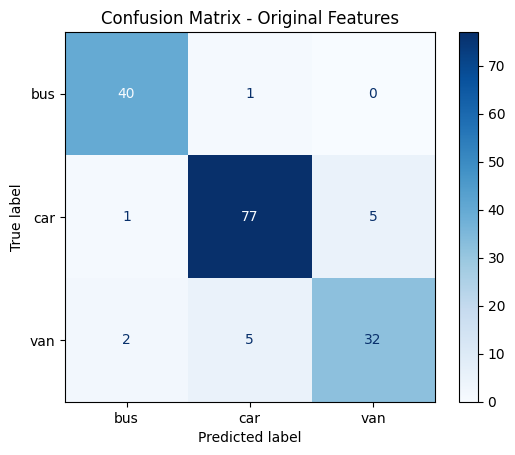

In [ ]:
evaluate_model(y_test, y_pred_raw, "Original Features")


PCA (3 Components)
              precision    recall  f1-score   support

         bus       0.85      0.71      0.77        41
         car       0.80      0.88      0.84        83
         van       0.63      0.62      0.62        39

    accuracy                           0.77       163
   macro avg       0.76      0.73      0.75       163
weighted avg       0.77      0.77      0.77       163



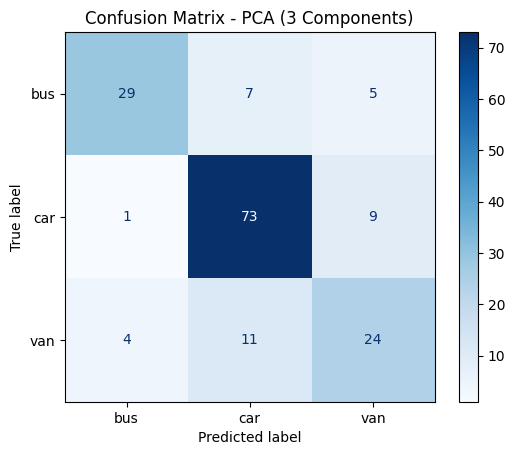

In [ ]:
evaluate_model(y_test, y_pred_pca3, "PCA (3 Components)")


PCA (5 Components)
              precision    recall  f1-score   support

         bus       0.75      0.80      0.78        41
         car       0.85      0.84      0.85        83
         van       0.70      0.67      0.68        39

    accuracy                           0.79       163
   macro avg       0.77      0.77      0.77       163
weighted avg       0.79      0.79      0.79       163



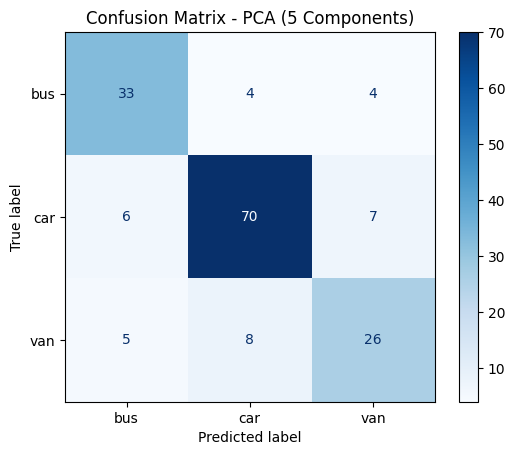

In [ ]:
evaluate_model(y_test, y_pred_pca5, "PCA (5 Components)")

### Evaluation and Confusion Matrix Analysis

To better understand the performance, we examined the **confusion matrix** and printed a **classification report** including:

- **Precision**: the proportion of correct positive predictions over all predicted positives  
  $ \text{Precision} = \frac{TP}{TP + FP} $
- **Recall**: the proportion of actual positives that were correctly identified  
  $ \text{Recall} = \frac{TP}{TP + FN} $
- **F1-score**: the harmonic mean of precision and recall  
  $ \text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} $

These metrics were computed for each class individually to highlight where the models performed well or struggled.

### Final Considerations

From the confusion matrices and classification metrics, we observed that the models using PCA, with either 3 or 5 components, performed noticeably worse than the model trained on the full feature set. This is expected, as reducing the number of features inevitably leads to some loss of information.

However, when comparing the PCA models, the difference in accuracy between using 5 components and just 3 components was **very small**.

Given this minor performance gap and the benefits of reduced dimensionality (lower complexity, faster computation, easier interpretation), we consider the use of **3 principal components** to be a **justified and effective choice** for this dataset.